In [6]:
import json
import pandas as pd
import argparse

def json_to_csv(json_path: str, csv_path: str):
    # Load JSON file
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    # Normalize the JSON into flat tabular structure
    df = pd.json_normalize(data, sep="_")

    # Optional: sort columns for better readability
    core_cols = [
        "id", "spotify_song_name", "spotify_artist_name", "youtube_title",
        "file_path", "lyrics_file_path", "release_date", "popularity", "track_url"
    ]
    audio_features = [
        "key", "bpm", "camelot", "duration", "acousticness", "danceability",
        "energy", "instrumentalness", "liveness", "loudness", "speechiness", "valence"
    ]

    # Reorder columns if all are found
    all_cols = core_cols + audio_features
    existing_cols = [col for col in all_cols if col in df.columns]
    df = df[existing_cols + [col for col in df.columns if col not in existing_cols]]

    # Save to CSV
    df.to_csv(csv_path, index=False)
    print(f"✅ Saved CSV to {csv_path}")

INPUT_JSON_PATH = "/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/data/song_details.json"
OUTPUT_CSV_PATH = "/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/data/song_details.csv"

json_to_csv(INPUT_JSON_PATH, OUTPUT_CSV_PATH)

✅ Saved CSV to /home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/data/song_details.csv


In [7]:
df = pd.read_csv(OUTPUT_CSV_PATH)

In [8]:
df["file_path"][0]

'/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/songs/Radiohead_-_Just.mp3'

In [9]:
df.shape

(20, 21)

In [11]:
#!/usr/bin/env python3
import os
import json
import pandas as pd

# === FUNCTIONS ===

def read_lyrics(lyrics_path: str) -> str:
    """Read the raw lyrics text from file."""
    try:
        with open(lyrics_path, "r", encoding="utf-8") as f:
            return f.read()
    except Exception as e:
        print(f"❌ Failed to read lyrics at {lyrics_path}: {e}")
        return ""

# apply read lyrics to df lyrics_path and create a new columns lyrics
def add_lyrics_to_df(df: pd.DataFrame) -> pd.DataFrame:
    """Add lyrics to DataFrame from file paths."""
    df["lyrics"] = df["lyrics_file_path"].apply(read_lyrics)
    return df

df = add_lyrics_to_df(df)



❌ Failed to read lyrics at nan: expected str, bytes or os.PathLike object, not float
❌ Failed to read lyrics at nan: expected str, bytes or os.PathLike object, not float
❌ Failed to read lyrics at nan: expected str, bytes or os.PathLike object, not float
❌ Failed to read lyrics at nan: expected str, bytes or os.PathLike object, not float
❌ Failed to read lyrics at nan: expected str, bytes or os.PathLike object, not float
❌ Failed to read lyrics at nan: expected str, bytes or os.PathLike object, not float
❌ Failed to read lyrics at nan: expected str, bytes or os.PathLike object, not float
❌ Failed to read lyrics at nan: expected str, bytes or os.PathLike object, not float
❌ Failed to read lyrics at nan: expected str, bytes or os.PathLike object, not float
❌ Failed to read lyrics at nan: expected str, bytes or os.PathLike object, not float


In [12]:
df.head()

,id,spotify_song_name,spotify_artist_name,youtube_title,file_path,lyrics_file_path,release_date,popularity,track_url,key,...,duration,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,lyrics
0,1,Just,Radiohead,Radiohead - Just,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1995-03-13,72,https://songdata.io/track/1dyTcli07c77mtQK3ahU...,G Minor,...,3:54,0.000401,0.291,8,0.012000,0.0763,-6.913,0.0862,0.359,Can't get the stink off\n\nHe's been hanging '...
1,2,Pretty Boy (feat. Lil Yachty),"Joji, Lil Yachty","Joji, Lil Yachty - Pretty Boy (feat. Lil Yachty)",/home/psyph3ri0n/Documents/projects-2025/sur/d...,NaN,2020-09-25,5,https://songdata.io/track/0f1G5SHFoFC9lO03gHCG...,F♯ Major,...,2:36,0.160000,0.656,8,0.378000,0.3720,-6.184,0.0672,0.638,
2,3,CAN'T GET OVER YOU (feat. Clams Casino),"Joji, Clams Casino","Joji, Clams Casino - CAN'T GET OVER YOU (feat....",/home/psyph3ri0n/Documents/projects-2025/sur/d...,NaN,2018-10-26,1,https://songdata.io/track/39oeKRgsLeynDIbWuXyA...,A Major,...,1:47,0.684000,0.900,3,0.077100,0.0853,-8.797,0.3320,0.844,
3,4,Someday,The Strokes,The Strokes - Someday,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2001-07-30,76,https://songdata.io/track/56NkIxSZZiMpFP5ZNSxt...,A Major,...,3:03,0.003300,0.542,5,0.000002,0.3380,-7.481,0.0301,0.671,"In many ways, they'll miss the good old days\n..."
4,5,Sinatra - 2005 Remaster,Deftones,Deftones - Sinatra - 2005 Remaster,/home/psyph3ri0n/Documents/projects-2025/sur/d...,NaN,2005,12,https://songdata.io/track/28EJ1ZhemS3OQmJdJegR...,A Major,...,4:43,0.000149,0.240,10,0.313000,0.1400,-4.305,0.0659,0.149,


In [13]:
df.drop(columns=["track_url", "youtube_title"], inplace=True)

In [14]:
df.head()

,id,spotify_song_name,spotify_artist_name,file_path,lyrics_file_path,release_date,popularity,key,bpm,camelot,duration,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,lyrics
0,1,Just,Radiohead,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1995-03-13,72,G Minor,176,6A,3:54,0.000401,0.291,8,0.012000,0.0763,-6.913,0.0862,0.359,Can't get the stink off\n\nHe's been hanging '...
1,2,Pretty Boy (feat. Lil Yachty),"Joji, Lil Yachty",/home/psyph3ri0n/Documents/projects-2025/sur/d...,NaN,2020-09-25,5,F♯ Major,156,2B,2:36,0.160000,0.656,8,0.378000,0.3720,-6.184,0.0672,0.638,
2,3,CAN'T GET OVER YOU (feat. Clams Casino),"Joji, Clams Casino",/home/psyph3ri0n/Documents/projects-2025/sur/d...,NaN,2018-10-26,1,A Major,130,11B,1:47,0.684000,0.900,3,0.077100,0.0853,-8.797,0.3320,0.844,
3,4,Someday,The Strokes,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2001-07-30,76,A Major,106,11B,3:03,0.003300,0.542,5,0.000002,0.3380,-7.481,0.0301,0.671,"In many ways, they'll miss the good old days\n..."
4,5,Sinatra - 2005 Remaster,Deftones,/home/psyph3ri0n/Documents/projects-2025/sur/d...,NaN,2005,12,A Major,84,11B,4:43,0.000149,0.240,10,0.313000,0.1400,-4.305,0.0659,0.149,


In [15]:
df.dropna(subset=["lyrics_file_path"], inplace=True)

In [16]:
df.shape

(10, 20)

In [17]:
df.head()

,id,spotify_song_name,spotify_artist_name,file_path,lyrics_file_path,release_date,popularity,key,bpm,camelot,duration,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,lyrics
0,1,Just,Radiohead,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1995-03-13,72,G Minor,176,6A,3:54,0.000401,0.291,8,0.012000,0.0763,-6.913,0.0862,0.359,Can't get the stink off\n\nHe's been hanging '...
3,4,Someday,The Strokes,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2001-07-30,76,A Major,106,11B,3:03,0.003300,0.542,5,0.000002,0.3380,-7.481,0.0301,0.671,"In many ways, they'll miss the good old days\n..."
5,6,Boys Don't Cry,The Cure,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1979-05-11,78,B Minor,169,10A,2:35,0.005170,0.462,8,0.000000,0.1800,-5.766,0.0621,0.671,I would say I'm sorry\n\nIf I thought that it ...
8,9,Last Nite,The Strokes,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2001-07-30,75,C Major,104,8B,3:13,0.028500,0.624,9,0.000198,0.0789,-5.703,0.0297,0.767,"Last night, she said\n\n""Oh, baby, I feel so d..."
11,12,About A Girl,Nirvana,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1989-06-01,77,B♭ Minor,157,3A,2:48,0.000033,0.436,9,0.000104,0.2050,-4.902,0.0647,0.512,"I need an easy friend\n\nI do, with an ear to ..."


In [18]:
# def read_lyrics(lyrics_path: str):
#     # Read the lyrics file
#     with open(lyrics_path, "r", encoding="utf-8") as f:
#         lyrics = f.read()
    
#     return lyrics
# def process_lyrics(lyrics: str):
#     # Split the lyrics into lines
#     lines = lyrics.split("<br>")
    
#     # Remove empty lines and strip whitespace
#     lines = [line.strip() for line in lines if line.strip()]
    
#     # Join the lines back together
#     processed_lyrics = "\n".join(lines)
    
#     return processed_lyrics

# # use the processed lyrics in a separate respective columns


In [19]:
df

,id,spotify_song_name,spotify_artist_name,file_path,lyrics_file_path,release_date,popularity,key,bpm,camelot,duration,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,lyrics
0,1,Just,Radiohead,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1995-03-13,72,G Minor,176,6A,3:54,0.000401,0.291,8,0.012000,0.0763,-6.913,0.0862,0.3590,Can't get the stink off\n\nHe's been hanging '...
3,4,Someday,The Strokes,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2001-07-30,76,A Major,106,11B,3:03,0.003300,0.542,5,0.000002,0.3380,-7.481,0.0301,0.6710,"In many ways, they'll miss the good old days\n..."
5,6,Boys Don't Cry,The Cure,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1979-05-11,78,B Minor,169,10A,2:35,0.005170,0.462,8,0.000000,0.1800,-5.766,0.0621,0.6710,I would say I'm sorry\n\nIf I thought that it ...
8,9,Last Nite,The Strokes,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2001-07-30,75,C Major,104,8B,3:13,0.028500,0.624,9,0.000198,0.0789,-5.703,0.0297,0.7670,"Last night, she said\n\n""Oh, baby, I feel so d..."
11,12,About A Girl,Nirvana,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1989-06-01,77,B♭ Minor,157,3A,2:48,0.000033,0.436,9,0.000104,0.2050,-4.902,0.0647,0.5120,"I need an easy friend\n\nI do, with an ear to ..."
13,14,This Night Has Opened My Eyes - 2011 Remaster,The Smiths,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1984,71,D Major,100,10B,3:41,0.001020,0.696,6,0.428000,0.2720,-8.407,0.0274,0.7010,"<!DOCTYPE html>\n<html lang=""en"">\n <head>\n ..."
14,15,Karma Police,Radiohead,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1997-05-28,84,G Major,75,9B,4:24,0.063800,0.360,5,0.000093,0.1720,-9.129,0.0258,0.3240,"Karma police, arrest this man\n\nHe talks in m..."
16,17,Reptilia,The Strokes,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2003-10-28,78,A Major,158,11B,3:39,0.000563,0.486,7,0.789000,0.1010,-5.084,0.0330,0.7410,He seemed impressed by the way you came in\n\n...
17,18,There Is a Light That Never Goes Out - 2011 Re...,The Smiths,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1986-06-16,82,D Minor,150,7A,4:04,0.027700,0.303,9,0.635000,0.1100,-2.352,0.0574,0.4910,"<!DOCTYPE html>\n<html lang=""en"">\n <head>\n ..."
19,20,Sextape,Deftones,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2008,79,F Major,90,7B,4:01,0.000824,0.367,6,0.075900,0.1160,-6.475,0.0270,0.0964,Floating under water ever changing picture\n\n...


In [20]:
df.shape

(10, 20)

In [21]:
print(df.head())

    id spotify_song_name spotify_artist_name  \
0    1              Just           Radiohead   
3    4           Someday         The Strokes   
5    6    Boys Don't Cry            The Cure   
8    9         Last Nite         The Strokes   
11  12      About A Girl             Nirvana   

                                            file_path  \
0   /home/psyph3ri0n/Documents/projects-2025/sur/d...   
3   /home/psyph3ri0n/Documents/projects-2025/sur/d...   
5   /home/psyph3ri0n/Documents/projects-2025/sur/d...   
8   /home/psyph3ri0n/Documents/projects-2025/sur/d...   
11  /home/psyph3ri0n/Documents/projects-2025/sur/d...   

                                     lyrics_file_path release_date  \
0   /home/psyph3ri0n/Documents/projects-2025/sur/d...   1995-03-13   
3   /home/psyph3ri0n/Documents/projects-2025/sur/d...   2001-07-30   
5   /home/psyph3ri0n/Documents/projects-2025/sur/d...   1979-05-11   
8   /home/psyph3ri0n/Documents/projects-2025/sur/d...   2001-07-30   
11  /home/psyph3ri

In [22]:
df.head()

,id,spotify_song_name,spotify_artist_name,file_path,lyrics_file_path,release_date,popularity,key,bpm,camelot,duration,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence,lyrics
0,1,Just,Radiohead,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1995-03-13,72,G Minor,176,6A,3:54,0.000401,0.291,8,0.012000,0.0763,-6.913,0.0862,0.359,Can't get the stink off\n\nHe's been hanging '...
3,4,Someday,The Strokes,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2001-07-30,76,A Major,106,11B,3:03,0.003300,0.542,5,0.000002,0.3380,-7.481,0.0301,0.671,"In many ways, they'll miss the good old days\n..."
5,6,Boys Don't Cry,The Cure,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1979-05-11,78,B Minor,169,10A,2:35,0.005170,0.462,8,0.000000,0.1800,-5.766,0.0621,0.671,I would say I'm sorry\n\nIf I thought that it ...
8,9,Last Nite,The Strokes,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2001-07-30,75,C Major,104,8B,3:13,0.028500,0.624,9,0.000198,0.0789,-5.703,0.0297,0.767,"Last night, she said\n\n""Oh, baby, I feel so d..."
11,12,About A Girl,Nirvana,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1989-06-01,77,B♭ Minor,157,3A,2:48,0.000033,0.436,9,0.000104,0.2050,-4.902,0.0647,0.512,"I need an easy friend\n\nI do, with an ear to ..."


In [24]:
df.drop(columns=["lyrics_file_path"], inplace=True)

In [77]:
df.head()

,id,spotify_song_name,spotify_artist_name,youtube_title,file_path,lyrics_file_path,release_date,popularity,track_url,key,...,camelot,duration,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,valence
0,1,Just,Radiohead,Radiohead - Just,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1995-03-13,72,https://songdata.io/track/1dyTcli07c77mtQK3ahU...,G Minor,...,6A,3:54,0.000401,0.291,8,0.012000,0.0763,-6.913,0.0862,0.359
1,2,Pretty Boy (feat. Lil Yachty),"Joji, Lil Yachty","Joji, Lil Yachty - Pretty Boy (feat. Lil Yachty)",/home/psyph3ri0n/Documents/projects-2025/sur/d...,NaN,2020-09-25,5,https://songdata.io/track/0f1G5SHFoFC9lO03gHCG...,F♯ Major,...,2B,2:36,0.160000,0.656,8,0.378000,0.3720,-6.184,0.0672,0.638
2,3,CAN'T GET OVER YOU (feat. Clams Casino),"Joji, Clams Casino","Joji, Clams Casino - CAN'T GET OVER YOU (feat....",/home/psyph3ri0n/Documents/projects-2025/sur/d...,NaN,2018-10-26,1,https://songdata.io/track/39oeKRgsLeynDIbWuXyA...,A Major,...,11B,1:47,0.684000,0.900,3,0.077100,0.0853,-8.797,0.3320,0.844
3,4,Someday,The Strokes,The Strokes - Someday,/home/psyph3ri0n/Documents/projects-2025/sur/d...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2001-07-30,76,https://songdata.io/track/56NkIxSZZiMpFP5ZNSxt...,A Major,...,11B,3:03,0.003300,0.542,5,0.000002,0.3380,-7.481,0.0301,0.671
4,5,Sinatra - 2005 Remaster,Deftones,Deftones - Sinatra - 2005 Remaster,/home/psyph3ri0n/Documents/projects-2025/sur/d...,NaN,2005,12,https://songdata.io/track/28EJ1ZhemS3OQmJdJegR...,A Major,...,11B,4:43,0.000149,0.240,10,0.313000,0.1400,-4.305,0.0659,0.149


In [25]:
print(df.columns)


Index(['id', 'spotify_song_name', 'spotify_artist_name', 'file_path',
       'release_date', 'popularity', 'key', 'bpm', 'camelot', 'duration',
       'acousticness', 'danceability', 'energy', 'instrumentalness',
       'liveness', 'loudness', 'speechiness', 'valence', 'lyrics'],
      dtype='object')


In [26]:
import os
import numpy as np
import librosa

AUDIO_DIR = "/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/songs"  # or wherever your .mp3s live
OUT_NUM_DIR = "/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/features/numerical"
SR = 22050
HOP_LENGTH = 512
WIN_LENGTH = 2048
TOP_DB = 30
N_MFCC = 13

os.makedirs(OUT_NUM_DIR, exist_ok=True)

def extract_features(audio_path):
    y, sr = librosa.load(audio_path, sr=SR)
    y, _ = librosa.effects.trim(y, top_db=TOP_DB)

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=WIN_LENGTH, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel)

    mfcc = librosa.feature.mfcc(S=mel_db, sr=sr, n_mfcc=N_MFCC)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=HOP_LENGTH)
    tonnetz = librosa.feature.tonnetz(y=librosa.effects.harmonic(y), sr=sr)
    rms = librosa.feature.rms(y=y)[0]
    zcr = librosa.feature.zero_crossing_rate(y)[0]

    def stats(x):
        return x.mean(axis=1), x.std(axis=1)

    return {
        "mfcc_mean": stats(mfcc)[0], "mfcc_std": stats(mfcc)[1],
        "chroma_mean": stats(chroma)[0], "chroma_std": stats(chroma)[1],
        "tonnetz_mean": stats(tonnetz)[0], "tonnetz_std": stats(tonnetz)[1],
        "rms_mean": np.mean(rms), "rms_std": np.std(rms),
        "zcr_mean": np.mean(zcr), "zcr_std": np.std(zcr),
    }


In [27]:
df.shape

(10, 19)

In [28]:
print(df["file_path"][0])

/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/songs/Radiohead_-_Just.mp3


In [29]:
# check if all the mp3 paths are valid

filepaths = df["file_path"].tolist()
for filepath in filepaths:
    if not os.path.exists(filepath):
       print("Validating file path:", filepath)
       print("❌ Invalid file path:", filepath)
       print("Please check the file path and try again.")
else:
    print("✅ All file paths are valid.")


✅ All file paths are valid.


In [30]:
import re
import os
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm



# Get the list of audio files from the DataFrame
audio_files = [Path(fpath) for fpath in df["file_path"] if os.path.exists(fpath)]

# List to store npz file paths
npz_paths = []

for fpath in tqdm(audio_files, desc="Extracting Audio Features"):
    try:
        # Assuming extract_features is defined
        features = extract_features(str(fpath))
        print(f"✅ {fpath.name} extracted successfully.")
        print(features)

        # Create a stem for the filename (clean up spaces, quotes, etc.)
        stem = fpath.stem.replace(" ", "_").replace("'", "")
        features = {k: v.flatten() for k, v in features.items()}

        # Remove anything between parentheses and the parentheses themselves
        stem = re.sub(r"\(.*?\)", "", stem)

        # Save features as .npz file
        npz_file_path = os.path.join(OUT_NUM_DIR, f"{stem}.npz")
        np.savez(npz_file_path, **features)
        print(f"✅ Saved features to {npz_file_path}")

        # Add the npz file path to the list
        npz_paths.append(npz_file_path)

    except Exception as e:
        print(f"❌ {fpath.name}: {e}")


# Save the updated DataFrame to CSV


Extracting Audio Features:  10%|█         | 1/10 [00:33<05:02, 33.61s/it]

✅ Radiohead_-_Just.mp3 extracted successfully.
{'mfcc_mean': array([-149.17218   ,   96.210884  ,  -24.14091   ,   49.38834   ,
          9.056607  ,    7.899065  ,    0.41031292,    6.5443387 ,
          0.6206307 ,    4.3796444 ,   -2.6730309 ,    5.237444  ,
         -6.1505423 ], dtype=float32), 'mfcc_std': array([75.749626 , 25.313923 , 27.961143 , 11.497823 , 11.061941 ,
        9.574513 ,  8.723718 ,  7.8474617,  8.048406 ,  7.7360783,
        7.261243 ,  6.921713 ,  6.7617354], dtype=float32), 'chroma_mean': array([0.50485224, 0.40183237, 0.42169252, 0.44501588, 0.4771804 ,
       0.40214208, 0.38306826, 0.42717713, 0.3560321 , 0.3778482 ,
       0.37114048, 0.38590798], dtype=float32), 'chroma_std': array([0.34331203, 0.26054686, 0.30108243, 0.29784915, 0.29299554,
       0.2985012 , 0.27164727, 0.29407442, 0.25104827, 0.2760937 ,
       0.2678726 , 0.26312178], dtype=float32), 'tonnetz_mean': array([-0.01724694,  0.03682056, -0.03505464,  0.04921405,  0.01561983,
        0.01

Extracting Audio Features:  20%|██        | 2/10 [00:57<03:42, 27.81s/it]

✅ The_Strokes_-_Someday.mp3 extracted successfully.
{'mfcc_mean': array([-34.37594   ,  90.68174   ,  -4.8623233 ,  30.51962   ,
        14.745224  ,  -3.3822448 ,  -6.7258863 ,   5.414262  ,
        -1.8133036 ,  -0.24691756,  -7.404322  ,  -0.25014845,
        -7.688173  ], dtype=float32), 'mfcc_std': array([64.45701  , 26.02192  , 16.661934 , 10.47345  ,  9.536403 ,
        7.772318 ,  6.930228 ,  7.0691814,  6.4389796,  6.571597 ,
        6.9189944,  6.239425 ,  6.535736 ], dtype=float32), 'chroma_mean': array([0.3388063 , 0.43917465, 0.3705262 , 0.36636952, 0.53653437,
       0.381546  , 0.40891585, 0.27268267, 0.4124638 , 0.567531  ,
       0.33755732, 0.38299245], dtype=float32), 'chroma_std': array([0.2183231 , 0.27097586, 0.28958985, 0.20647131, 0.35454997,
       0.22208   , 0.31752294, 0.19520737, 0.27000985, 0.306593  ,
       0.20331062, 0.29244438], dtype=float32), 'tonnetz_mean': array([ 0.20486981, -0.16453627, -0.10751019,  0.02175216, -0.00337782,
        0.00548667])

Extracting Audio Features:  30%|███       | 3/10 [01:16<02:47, 23.96s/it]

...

✅ The_Strokes_-_Reptilia.mp3 extracted successfully.
{'mfcc_mean': array([-35.240463  , 102.66873   , -19.590977  ,  27.226461  ,
        12.7489395 ,   8.100748  ,  -0.97475326,   6.6468472 ,
        -1.8889549 ,   2.5880604 ,  -3.260664  ,   1.343367  ,
        -1.147768  ], dtype=float32), 'mfcc_std': array([77.63626  , 35.95163  , 26.148811 , 11.80491  , 11.736246 ,
       11.026133 ,  8.445515 ,  8.460055 ,  7.3900223,  7.0326657,
        7.321758 ,  6.803608 ,  6.5911093], dtype=float32), 'chroma_mean': array([0.43922904, 0.37876007, 0.4253146 , 0.39646372, 0.42969918,
       0.31259203, 0.31284845, 0.27220115, 0.33373007, 0.37349838,
       0.4104092 , 0.63613135], dtype=float32), 'chroma_std': array([0.25497934, 0.28772485, 0.31430158, 0.26908907, 0.3724832 ,
       0.23869723, 0.24734765, 0.25986424, 0.26818886, 0.29407036,
       0.2411653 , 0.33554035], dtype=float32), 'tonnetz_mean': array([ 0.14295445, -0.1683126 ,  0.14297605,  0.0195359 , -0.03666627,
       -0.03682616]

Extracting Audio Features:  90%|█████████ | 9/10 [04:00<00:27, 27.89s/it]

✅ The_Smiths_-_There_Is_a_Light_That_Never_Goes_Out_-_2011_Remaster.mp3 extracted successfully.
{'mfcc_mean': array([-32.235435 ,  86.63745  ,  -3.6101935,  22.659536 ,  -2.5274825,
         9.829378 ,   0.5931127,  10.459499 ,  -4.7049212,  10.168938 ,
         1.7719591,   4.225374 ,  -4.0725226], dtype=float32), 'mfcc_std': array([51.984013 , 23.382698 , 16.640821 , 10.589797 ,  9.141625 ,
        7.7846565,  8.105365 ,  7.287823 ,  9.708437 ,  7.953085 ,
        7.0668287,  7.2071795,  7.055557 ], dtype=float32), 'chroma_mean': array([0.26533052, 0.29985398, 0.24131554, 0.48156175, 0.45611253,
       0.28115797, 0.39973393, 0.34488508, 0.55535775, 0.36410943,
       0.31155598, 0.45800245], dtype=float32), 'chroma_std': array([0.18098131, 0.2927132 , 0.1819826 , 0.29945374, 0.31869206,
       0.2003452 , 0.31590924, 0.23627493, 0.3417469 , 0.26322162,
       0.216024  , 0.336524  ], dtype=float32), 'tonnetz_mean': array([ 0.00957773, -0.23038365,  0.03491375,  0.06830809, -0.013079

Extracting Audio Features: 100%|██████████| 10/10 [04:30<00:00, 27.05s/it]

✅ Deftones_-_Sextape.mp3 extracted successfully.
{'mfcc_mean': array([-81.17691  , 103.7505   ,   3.7801392,  31.407913 ,   6.991492 ,
        11.801957 ,  10.093846 ,  14.285086 ,   0.7526295,   8.324422 ,
         1.6090391,   2.2307937,  -3.4845827], dtype=float32), 'mfcc_std': array([103.057175 ,  40.49704  ,  21.453413 ,  12.952857 ,  11.625831 ,
         8.943882 ,   9.612733 ,   8.418431 ,   8.68884  ,   9.719468 ,
         6.8737655,   7.824694 ,   8.091142 ], dtype=float32), 'chroma_mean': array([0.5061719 , 0.31806478, 0.292051  , 0.27556613, 0.54973894,
       0.38160962, 0.3797084 , 0.47806627, 0.36470124, 0.43547434,
       0.35882664, 0.5600269 ], dtype=float32), 'chroma_std': array([0.32070613, 0.18555874, 0.24053212, 0.17829096, 0.33406332,
       0.29803818, 0.23668866, 0.30881256, 0.22331965, 0.34516615,
       0.23067524, 0.31032327], dtype=float32), 'tonnetz_mean': array([ 0.1772797 ,  0.19592887, -0.04373242,  0.17549525, -0.00022265,
        0.06077302]), 'tonnetz

In [31]:
audio_files = [Path(fpath) for fpath in df["file_path"]]
print(len(audio_files))
# # Assuming your DataFrame is called 'df', add the npz paths to a new column
df['npz_paths'] = npz_paths

# Check the updated DataFrame
print(df[['spotify_song_name', 'npz_paths']].head())

10
   spotify_song_name                                          npz_paths
0               Just  /home/psyph3ri0n/Documents/projects-2025/sur/d...
3            Someday  /home/psyph3ri0n/Documents/projects-2025/sur/d...
5     Boys Don't Cry  /home/psyph3ri0n/Documents/projects-2025/sur/d...
8          Last Nite  /home/psyph3ri0n/Documents/projects-2025/sur/d...
11      About A Girl  /home/psyph3ri0n/Documents/projects-2025/sur/d...


In [32]:
# write a function to load the files and the key values
def load_features(features_dir: str):
    features = {}
    for fpath in Path(features_dir).glob("*.npz"):
        stem = fpath.stem.replace(" ", "_").replace("'", "")
        features[stem] = np.load(str(fpath))
    return features


features = load_features(OUT_NUM_DIR)
features.keys()

dict_keys(['Nirvana_-_About_A_Girl_MTV_Unplugged', 'Radiohead_-_High_and_Dry', 'There_Is_a_Light_That_Never_Goes_Out_2011_Remaster', 'The_Smiths_-_This_Night_Has_Opened_My_Eyes_Official_Audio', 'The_Strokes_-_Last_Nite', 'The_Cure_-_Boys_Dont_Cry', 'Radiohead_-_Just', 'The_Strokes_-_Reptilia', 'WuShang_Clan_feat._@DankRishu_\u200b', 'Deftones_-_Sextape', 'Nirvana_-_Dumb', 'Nirvana_-_All_Apologies', 'The_Strokes_-_Someday_Official_HD_Video', 'This_Charming_Man_2008_Remaster', 'The_Smiths_-_This_Night_Has_Opened_My_Eyes_-_2011_Remaster', 'Joji_ft._Clams_Casino_-_CANT_GET_OVER_YOU', 'The_Strokes_-_Reptilia_Official_HD_Video', 'Joji_-_Pretty_Boy_ft._Lil_Yachty', 'The_Smiths_-_There_Is_a_Light_That_Never_Goes_Out_-_2011_Remaster', 'The_Strokes_-_The_Adults_Are_Talking_Official_Video', 'Nirvana_-_All_Apologies_MTV_Unplugged', 'The_Strokes_-_Last_Nite_Official_HD_Video', 'The_Strokes_-_Someday', 'Sinatra_2005_Remaster', 'Radiohead_-_Karma_Police', 'Deftones_-_Sextape_[Official_Music_Video]', 

In [33]:
# features['The_Strokes_-_Someday_']["rms_mean"]

In [34]:
df.columns

Index(['id', 'spotify_song_name', 'spotify_artist_name', 'file_path',
       'release_date', 'popularity', 'key', 'bpm', 'camelot', 'duration',
       'acousticness', 'danceability', 'energy', 'instrumentalness',
       'liveness', 'loudness', 'speechiness', 'valence', 'lyrics',
       'npz_paths'],
      dtype='object')

In [35]:
# Function to convert duration in 'MM:SS' format to total seconds
def convert_duration_to_seconds(duration):
    minutes, seconds = map(int, duration.split(':'))
    return minutes * 60 + seconds

# Apply the function to the 'duration' column
df['duration'] = df['duration'].apply(convert_duration_to_seconds)

# Check the result
print(df[['spotify_song_name', 'duration']].head())


   spotify_song_name  duration
0               Just       234
3            Someday       183
5     Boys Don't Cry       155
8          Last Nite       193
11      About A Girl       168


In [36]:
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# List of numeric columns to scale
numeric_columns = [
    'bpm', 'duration', 'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'loudness', 'speechiness', 'valence', 'popularity'
]

# Select only numeric columns for scaling
df_numeric = df[numeric_columns]

# Normalize all metadata features to [0, 1] for fair fusion
scaler = MinMaxScaler()
df[numeric_columns] = scaler.fit_transform(df_numeric)

# Label encoding for 'key'
df['key_encoded'] = LabelEncoder().fit_transform(df['key'])

# Label encoding for 'camelot'
df['camelot_encoded'] = LabelEncoder().fit_transform(df['camelot'])

# Save as vector for fusion (creating a metadata vector)
# Concatenate all encoded and scaled columns
df['meta_vector'] = df[numeric_columns + ['camelot_encoded', 'key_encoded']].apply(lambda row: row.values, axis=1)

# Check the result
print(df.head())


    id spotify_song_name spotify_artist_name  \
0    1              Just           Radiohead   
3    4           Someday         The Strokes   
5    6    Boys Don't Cry            The Cure   
8    9         Last Nite         The Strokes   
11  12      About A Girl             Nirvana   

                                            file_path release_date  \
0   /home/psyph3ri0n/Documents/projects-2025/sur/d...   1995-03-13   
3   /home/psyph3ri0n/Documents/projects-2025/sur/d...   2001-07-30   
5   /home/psyph3ri0n/Documents/projects-2025/sur/d...   1979-05-11   
8   /home/psyph3ri0n/Documents/projects-2025/sur/d...   2001-07-30   
11  /home/psyph3ri0n/Documents/projects-2025/sur/d...   1989-06-01   

    popularity       key       bpm camelot  duration  ...  instrumentalness  \
0     0.076923   G Minor  1.000000      6A  0.724771  ...          0.015209   
3     0.384615   A Major  0.306931     11B  0.256881  ...          0.000003   
5     0.538462   B Minor  0.930693     10A  0.000000 

In [37]:
df.head()

,id,spotify_song_name,spotify_artist_name,file_path,release_date,popularity,key,bpm,camelot,duration,...,instrumentalness,liveness,loudness,speechiness,valence,lyrics,npz_paths,key_encoded,camelot_encoded,meta_vector
0,1,Just,Radiohead,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1995-03-13,0.076923,G Minor,1.000000,6A,0.724771,...,0.015209,0.000000,0.326988,1.000000,0.391590,Can't get the stink off\n\nHe's been hanging '...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,8,4,"[1.0, 0.7247706422018347, 0.005766332584248518..."
3,4,Someday,The Strokes,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2001-07-30,0.384615,A Major,0.306931,11B,0.256881,...,0.000003,1.000000,0.243175,0.071192,0.856845,"In many ways, they'll miss the good old days\n...",/home/psyph3ri0n/Documents/projects-2025/sur/d...,0,2,"[0.306930693069307, 0.25688073394495414, 0.051..."
5,6,Boys Don't Cry,The Cure,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1979-05-11,0.538462,B Minor,0.930693,10A,0.000000,...,0.000000,0.396255,0.496237,0.600993,0.856845,I would say I'm sorry\n\nIf I thought that it ...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1,0,"[0.9306930693069306, 0.0, 0.08055458413247041,..."
8,9,Last Nite,The Strokes,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2001-07-30,0.307692,C Major,0.287129,8B,0.348624,...,0.000251,0.009935,0.505533,0.064570,1.000000,"Last night, she said\n\n""Oh, baby, I feel so d...",/home/psyph3ri0n/Documents/projects-2025/sur/d...,3,7,"[0.28712871287128716, 0.3486238532110091, 0.44..."
11,12,About A Girl,Nirvana,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1989-06-01,0.461538,B♭ Minor,0.811881,3A,0.119266,...,0.000132,0.491784,0.623727,0.644040,0.619744,"I need an easy friend\n\nI do, with an ear to ...",/home/psyph3ri0n/Documents/projects-2025/sur/d...,2,3,"[0.8118811881188119, 0.11926605504587151, 0.0,..."


In [41]:
from sentence_transformers import SentenceTransformer
# from .autonotebook import tqdm as notebook_tqdm

model = SentenceTransformer("all-MiniLM-L6-v2")

# Embed processed lyrics into 384-dim semantic space
df['lyric_vector'] = df['lyrics'].apply(lambda x: model.encode(x, show_progress_bar=False))


In [42]:
df['lyric_vector'].head()

0     [0.051608708, 0.0035969482, 0.080358095, 0.014...
3     [-0.08818313, -0.04205173, 0.069796056, 0.0136...
5     [-0.10971933, 0.00159445, 0.052013785, -0.0345...
8     [-0.047923032, -0.03863722, 0.056662306, 0.030...
11    [-0.12285279, -0.057854682, 0.07477126, -0.011...
Name: lyric_vector, dtype: object

In [43]:
import numpy as np
import os
import re
def load_audio_vector(row, feature_dir="/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/features/numerical"):
    name = os.path.basename(row['file_path']).replace(".mp3", "").replace(" ", "_")
    # remove anything in between (parentheses) in the filename and also the parenthesis using regex
    name = re.sub(r"\s*\(.*?\)", "", name)
    npz_path = os.path.join(feature_dir, f"{name}.npz")
    print(npz_path)
    try:
        features = np.load(npz_path)
        full_vec = []
        """
        "mfcc_mean": stats(mfcc)[0], "mfcc_std": stats(mfcc)[1],
        "chroma_mean": stats(chroma)[0], "chroma_std": stats(chroma)[1],
        "tonnetz_mean": stats(tonnetz)[0], "tonnetz_std": stats(tonnetz)[1],
        "rms_mean": np.mean(rms), "rms_std": np.std(rms),
        "zcr_mean": np.mean(zcr), "zcr_std": np.std(zcr),
        """
        for key in ['mfcc_mean', 'mfcc_std', 'chroma_mean', 'chroma_std', 'tonnetz_mean', 'tonnetz_std',
                    'rms_mean', 'rms_std', 'zcr_mean', 'zcr_std']:
            val = features[key]
            full_vec.extend(val if isinstance(val, (np.ndarray, list)) else [val])
        return np.array(full_vec)
    except:
        return None

df['audio_vector'] = df.apply(load_audio_vector, axis=1)


/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/features/numerical/Radiohead_-_Just.npz
/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/features/numerical/The_Strokes_-_Someday.npz
/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/features/numerical/The_Cure_-_Boys_Don't_Cry.npz
/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/features/numerical/The_Strokes_-_Last_Nite.npz
/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/features/numerical/Nirvana_-_About_A_Girl.npz
/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/features/numerical/The_Smiths_-_This_Night_Has_Opened_My_Eyes_-_2011_Remaster.npz
/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/features/numerical/Radiohead_-_Karma_Police.npz
/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/features/numerical/The_Strokes_-_Reptilia.npz
/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/fea

In [44]:
df

,id,spotify_song_name,spotify_artist_name,file_path,release_date,popularity,key,bpm,camelot,duration,...,loudness,speechiness,valence,lyrics,npz_paths,key_encoded,camelot_encoded,meta_vector,lyric_vector,audio_vector
0,1,Just,Radiohead,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1995-03-13,0.076923,G Minor,1.000000,6A,0.724771,...,0.326988,1.000000,0.391590,Can't get the stink off\n\nHe's been hanging '...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,8,4,"[1.0, 0.7247706422018347, 0.005766332584248518...","[0.051608708, 0.0035969482, 0.080358095, 0.014...","[-149.17218017578125, 96.21088409423828, -24.1..."
3,4,Someday,The Strokes,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2001-07-30,0.384615,A Major,0.306931,11B,0.256881,...,0.243175,0.071192,0.856845,"In many ways, they'll miss the good old days\n...",/home/psyph3ri0n/Documents/projects-2025/sur/d...,0,2,"[0.306930693069307, 0.25688073394495414, 0.051...","[-0.08818313, -0.04205173, 0.069796056, 0.0136...","[-34.375938415527344, 90.6817398071289, -4.862..."
5,6,Boys Don't Cry,The Cure,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1979-05-11,0.538462,B Minor,0.930693,10A,0.000000,...,0.496237,0.600993,0.856845,I would say I'm sorry\n\nIf I thought that it ...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1,0,"[0.9306930693069306, 0.0, 0.08055458413247041,...","[-0.10971933, 0.00159445, 0.052013785, -0.0345...",None
8,9,Last Nite,The Strokes,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2001-07-30,0.307692,C Major,0.287129,8B,0.348624,...,0.505533,0.064570,1.000000,"Last night, she said\n\n""Oh, baby, I feel so d...",/home/psyph3ri0n/Documents/projects-2025/sur/d...,3,7,"[0.28712871287128716, 0.3486238532110091, 0.44...","[-0.047923032, -0.03863722, 0.056662306, 0.030...","[-8.28770637512207, 103.89665222167969, -42.77..."
11,12,About A Girl,Nirvana,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1989-06-01,0.461538,B♭ Minor,0.811881,3A,0.119266,...,0.623727,0.644040,0.619744,"I need an easy friend\n\nI do, with an ear to ...",/home/psyph3ri0n/Documents/projects-2025/sur/d...,2,3,"[0.8118811881188119, 0.11926605504587151, 0.0,...","[-0.12285279, -0.057854682, 0.07477126, -0.011...","[-80.27008819580078, 97.85627746582031, -9.003..."
13,14,This Night Has Opened My Eyes - 2011 Remaster,The Smiths,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1984,0.000000,D Major,0.247525,10B,0.605505,...,0.106537,0.026490,0.901581,"<!DOCTYPE html>\n<html lang=""en"">\n <head>\n ...",/home/psyph3ri0n/Documents/projects-2025/sur/d...,4,1,"[0.24752475247524752, 0.6055045871559632, 0.01...","[-0.06721554, 0.041562974, -0.06384264, 0.0420...","[-108.8819351196289, 79.27777099609375, -0.858..."
14,15,Karma Police,Radiohead,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1997-05-28,1.000000,G Major,0.000000,9B,1.000000,...,0.000000,0.000000,0.339398,"Karma police, arrest this man\n\nHe talks in m...",/home/psyph3ri0n/Documents/projects-2025/sur/d...,7,8,"[0.0, 1.0, 1.0, 0.1703703703703704, 0.0, 0.000...","[-0.08489179, 0.005509431, -0.00069222157, -0....","[-165.54844665527344, 101.79766845703125, 9.65..."
16,17,Reptilia,The Strokes,/home/psyph3ri0n/Documents/projects-2025/sur/d...,2003-10-28,0.538462,A Major,0.821782,11B,0.587156,...,0.596872,0.119205,0.961229,He seemed impressed by the way you came in\n\n...,/home/psyph3ri0n/Documents/projects-2025/sur/d...,0,2,"[0.8217821782178218, 0.5871559633027523, 0.008...","[0.0021836758, 0.007279497, 0.01944993, 0.0424...","[-35.24046325683594, 102.66873168945312, -19.5..."
17,18,There Is a Light That Never Goes Out - 2011 Re...,The Smiths,/home/psyph3ri0n/Documents/projects-2025/sur/d...,1986-06-16,0.846154,D Minor,0.742574,7A,0.816514,...,1.000000,0.523179,0.588428,"<!DOCTYPE html>\n<html lang=""en"">\n <head>\n ...",/home/psyph3ri0n/Documents/projects-2025/sur/d...,5,5,"[0.7425742574257426, 0.8165137614678897, 0.433...","[-0.06721554, 0.041562974, -0.06384264, 0.0420...","[-32.235435485839844, 86.637451171875, -3.6101.

In [45]:
df['audio_vector'].head()

0     [-149.17218017578125, 96.21088409423828, -24.1...
3     [-34.375938415527344, 90.6817398071289, -4.862...
5                                                  None
8     [-8.28770637512207, 103.89665222167969, -42.77...
11    [-80.27008819580078, 97.85627746582031, -9.003...
Name: audio_vector, dtype: object

In [46]:
def normalize_filename(filename: str) -> str:
    name = os.path.basename(filename).replace(".mp3", "")
    name = re.sub(r"\s*\(.*?\)", "", name)  # remove text in parentheses
    name = name.replace(" ", "_").replace("'", "").strip("_")
    # Remove any leading or trailing underscores
    return name
# write a function to load the files and the key values
def load_features(features_dir: str):
    features = {}
    for fpath in Path(features_dir).glob("*.npz"):
        stem = fpath.stem.replace(" ", "_").replace("'", "")

        features[stem] = np.load(str(fpath))
    return features


features = load_features(OUT_NUM_DIR)
features.keys()


dict_keys(['Nirvana_-_About_A_Girl_MTV_Unplugged', 'Radiohead_-_High_and_Dry', 'There_Is_a_Light_That_Never_Goes_Out_2011_Remaster', 'The_Smiths_-_This_Night_Has_Opened_My_Eyes_Official_Audio', 'The_Strokes_-_Last_Nite', 'The_Cure_-_Boys_Dont_Cry', 'Radiohead_-_Just', 'The_Strokes_-_Reptilia', 'WuShang_Clan_feat._@DankRishu_\u200b', 'Deftones_-_Sextape', 'Nirvana_-_Dumb', 'Nirvana_-_All_Apologies', 'The_Strokes_-_Someday_Official_HD_Video', 'This_Charming_Man_2008_Remaster', 'The_Smiths_-_This_Night_Has_Opened_My_Eyes_-_2011_Remaster', 'Joji_ft._Clams_Casino_-_CANT_GET_OVER_YOU', 'The_Strokes_-_Reptilia_Official_HD_Video', 'Joji_-_Pretty_Boy_ft._Lil_Yachty', 'The_Smiths_-_There_Is_a_Light_That_Never_Goes_Out_-_2011_Remaster', 'The_Strokes_-_The_Adults_Are_Talking_Official_Video', 'Nirvana_-_All_Apologies_MTV_Unplugged', 'The_Strokes_-_Last_Nite_Official_HD_Video', 'The_Strokes_-_Someday', 'Sinatra_2005_Remaster', 'Radiohead_-_Karma_Police', 'Deftones_-_Sextape_[Official_Music_Video]', 

In [60]:
def fuse_vectors(row):
    vectors = []
    for key in ['lyric_vector', 'audio_vector', 'meta_vector']:
        vec = row.get(key)
        if vec is None or not isinstance(vec, (np.ndarray, list)):
            return None  # skip this row entirely
        vec = np.array(vec)
        vectors.append(vec)
    
    # Ensure all vectors have consistent 1D shape
    if not all(v.ndim == 1 for v in vectors):
        return None
    
    return np.concatenate(vectors)
df['embedding'] = df.apply(fuse_vectors, axis=1)

# Inspect what got filtered
bad_rows = df[df['embedding'].isna()]
# drop the bad row
# Drop the bad rows with malformed vectors
df = df.dropna(subset=['embedding']).reset_index(drop=True)

print("✅ Cleaned dataset: all rows have valid embeddings now.")



✅ Cleaned dataset: all rows have valid embeddings now.


In [62]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def recommend(song_id, top_n=1):
    # Ensure the query vector is correctly shaped
    query_vec = df[df['id'] == song_id]['embedding'].values[0]
    
    # Flatten the embedding if necessary (ensure it's a 1D array)
    if query_vec.ndim > 1:
        query_vec = query_vec.flatten()
    
    query_vec = query_vec.reshape(1, -1)
    
    # Prepare the candidate DataFrame
    candidate_df = df[df['id'] != song_id].copy()

    # Ensure all embeddings are properly shaped and handled
    def flatten_embedding(embedding):
        # Flatten if necessary and handle missing/NaN embeddings
        if isinstance(embedding, np.ndarray) and embedding.ndim > 1:
            embedding = embedding.flatten()
        if isinstance(embedding, list):
            embedding = np.array(embedding)
        return embedding

    # Apply the flattening function to all embeddings in the candidate DataFrame
    candidate_df['embedding'] = candidate_df['embedding'].apply(flatten_embedding)
    
    # Now we stack the embeddings for cosine similarity calculation
    try:
        candidate_embeddings = np.stack(candidate_df['embedding'])
    except ValueError as e:
        print(f"Error stacking embeddings: {e}")
        return None

    # Compute cosine similarity
    candidate_df['similarity'] = cosine_similarity(query_vec, candidate_embeddings)[0]
    
    # Sort and return top_n recommendations
    return candidate_df.sort_values(by="similarity", ascending=False)[
        ['spotify_song_name', 'spotify_artist_name', 'similarity']
    ].head(top_n)

# Test the function
recommend(1)


,spotify_song_name,spotify_artist_name,similarity
5,Karma Police,Radiohead,0.975819


In [63]:
df["embedding"]

0    [0.05160870775580406, 0.0035969482269138098, 0...
1    [-0.08818312734365463, -0.04205172881484032, 0...
2    [-0.04792303219437599, -0.03863722085952759, 0...
3    [-0.12285278737545013, -0.057854682207107544, ...
4    [-0.06721553951501846, 0.04156297445297241, -0...
5    [-0.08489178866147995, 0.005509431008249521, -...
6    [0.002183675765991211, 0.007279497105628252, 0...
7    [-0.06721553951501846, 0.04156297445297241, -0...
8    [-0.05460585281252861, 0.027491046115756035, 0...
Name: embedding, dtype: object

In [72]:
df["id"]

0     1
1     4
2     9
3    12
4    14
5    15
6    17
7    18
8    20
Name: id, dtype: int64

In [71]:
df["spotify_song_name"]

0                                                 Just
1                                              Someday
2                                            Last Nite
3                                         About A Girl
4        This Night Has Opened My Eyes - 2011 Remaster
5                                         Karma Police
6                                             Reptilia
7    There Is a Light That Never Goes Out - 2011 Re...
8                                              Sextape
Name: spotify_song_name, dtype: object

In [81]:
df[["spotify_song_name", "id"]]

,spotify_song_name,id
0,Just,1
1,Someday,4
2,Last Nite,9
3,About A Girl,12
4,This Night Has Opened My Eyes - 2011 Remaster,14
5,Karma Police,15
6,Reptilia,17
7,There Is a Light That Never Goes Out - 2011 Re...,18
8,Sextape,20


In [82]:
df[df["id"] == 9][["spotify_song_name", "embedding"]]

,spotify_song_name,embedding
2,Last Nite,"[-0.04792303219437599, -0.03863722085952759, 0..."


In [83]:
recommend(9, top_n=4)

,spotify_song_name,spotify_artist_name,similarity
6,Reptilia,The Strokes,0.937356
1,Someday,The Strokes,0.914923
7,There Is a Light That Never Goes Out - 2011 Re...,The Smiths,0.908590
3,About A Girl,Nirvana,0.835632


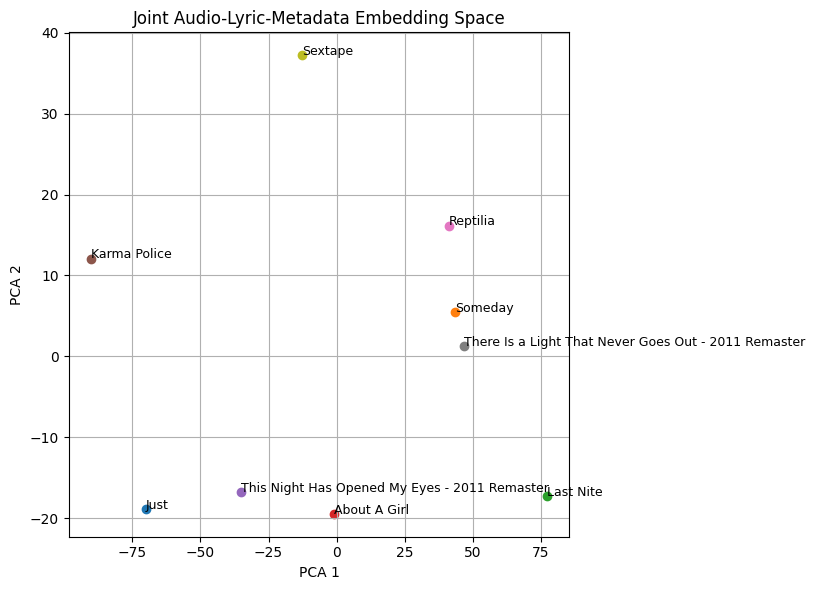

In [84]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

valid_df = df[df['embedding'].notnull()]
embeddings = np.stack(valid_df['embedding'])

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
for i, row in valid_df.iterrows():
    plt.scatter(reduced[i, 0], reduced[i, 1])
    plt.text(reduced[i, 0]+0.01, reduced[i, 1]+0.01, row['spotify_song_name'], fontsize=9)
plt.title("Joint Audio-Lyric-Metadata Embedding Space")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.tight_layout()
plt.show()


In [86]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path

# --- CONFIG ---
AUDIO_DIR = "/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/songs"  # change to your audio dir
OUT_DIR = "/home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/visuals"
SR = 22050
N_MELS = 128
HOP_LENGTH = 512

os.makedirs(OUT_DIR, exist_ok=True)

# --- Get files ---
files = list(Path(AUDIO_DIR).glob("*.mp3"))
if len(files) > 5:
    files = random.sample(files, 5)

# --- Plotting Function ---
def plot_audio_representations(filepath, outdir):
    y, sr = librosa.load(filepath, sr=SR)
    title = Path(filepath).stem

    fig, axs = plt.subplots(3, 1, figsize=(12, 10))

    # --- Waveform ---
    librosa.display.waveshow(y, sr=sr, ax=axs[0])
    axs[0].set(title=f"Waveform: {title}")
    axs[0].label_outer()

    # --- Mel Spectrogram ---
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, hop_length=HOP_LENGTH, ax=axs[1],
                                   x_axis='time', y_axis='mel', cmap='magma')
    axs[1].set(title="Mel Spectrogram")
    fig.colorbar(img, ax=axs[1], format="%+2.0f dB")

    # --- Chromagram ---
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=HOP_LENGTH)
    img = librosa.display.specshow(chroma, x_axis='time', y_axis='chroma', sr=sr,
                                   hop_length=HOP_LENGTH, ax=axs[2], cmap='coolwarm')
    axs[2].set(title='Chromagram')
    fig.colorbar(img, ax=axs[2])

    plt.tight_layout()
    outfile = os.path.join(outdir, f"{title}_visuals.png")
    plt.savefig(outfile)
    plt.close()
    print(f"✅ Saved: {outfile}")

# --- Loop and Generate ---
for f in files:
    plot_audio_representations(str(f), OUT_DIR)


✅ Saved: /home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/visuals/WuShang_Clan_feat._@DankRishu_​_visuals.png
✅ Saved: /home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/visuals/The_Strokes_-_Reptilia_visuals.png
✅ Saved: /home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/visuals/The_Strokes_-_Someday_visuals.png
✅ Saved: /home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/visuals/Nirvana_-_Dumb_visuals.png
✅ Saved: /home/psyph3ri0n/Documents/projects-2025/sur/downloads/spoti-test/visuals/Joji_-_Pretty_Boy_ft._Lil_Yachty_visuals.png
